In [1]:
import tensorflow 
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten

In [2]:
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

11490434/11490434 [==============================] - 38s 3us/step


In [3]:
X_train.shape

(60000, 28, 28)

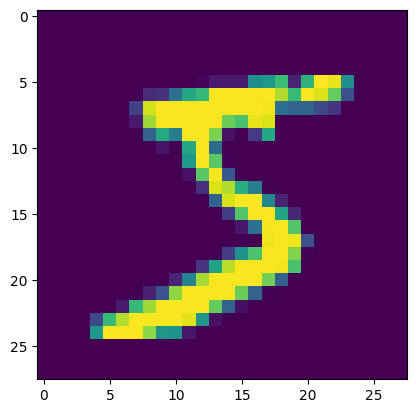

In [5]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])

In [6]:
X_train=X_train/255
X_test=X_test/255

In [15]:
model=Sequential()
model.add(Flatten(input_shape=(28,28)))
#model.add(Dense(128,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [16]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_2 (Dense)             (None, 128)               100480    
                                                                 
 dense_3 (Dense)             (None, 32)                4128      
                                                                 
 dense_4 (Dense)             (None, 10)                330       
                                                                 
Total params: 104,938
Trainable params: 104,938
Non-trainable params: 0
_________________________________________________________________


In [17]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [19]:
history=model.fit(X_train,y_train,epochs=25,validation_split=0.2)

Epoch 1/25
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0065 - accuracy: 0.9978 - val_loss: 0.2011 - val_accuracy: 0.9744
Epoch 2/25
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0087 - accuracy: 0.9971 - val_loss: 0.1862 - val_accuracy: 0.9772
Epoch 3/25
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0069 - accuracy: 0.9980 - val_loss: 0.1764 - val_accuracy: 0.9748
Epoch 4/25
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0079 - accuracy: 0.9977 - val_loss: 0.1809 - val_accuracy: 0.9761
Epoch 5/25
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0058 - accuracy: 0.9981 - val_loss: 0.1892 - val_accuracy: 0.9747
Epoch 6/25
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0094 - accuracy: 0.9971 - val_loss: 0.2051 - val_accuracy: 0.9746
Epoch 7/25
1500/1500 [==============================] - 3s 2ms/step - loss: 0.0047 - accuracy: 0.9985 - val_loss: 0.1868 - val_accuracy:

In [20]:
y_prob=model.predict(X_test)

313/313 [==============================] - 0s 1ms/step


In [21]:
y_pred=y_prob.argmax(axis=1)

In [22]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9763

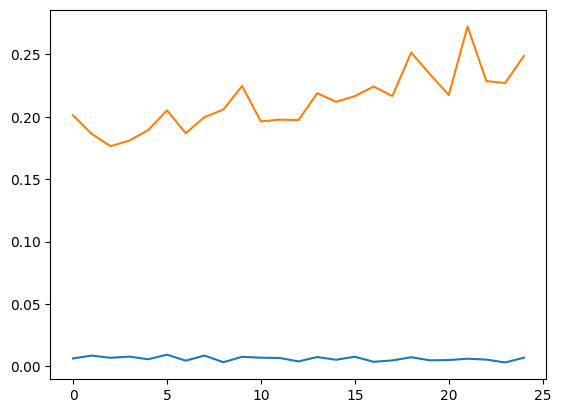

In [23]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

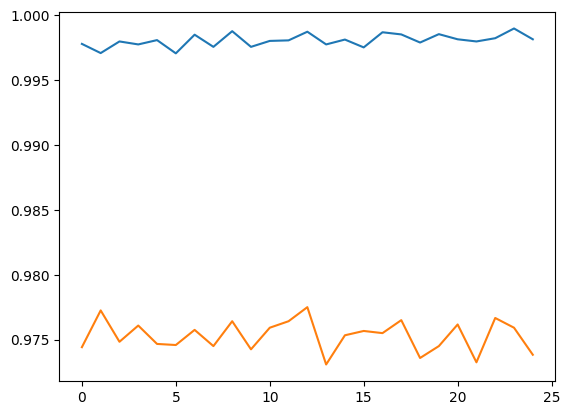

In [24]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [25]:
print(tensorflow.config.list_logical_devices('GPU'))

[LogicalDevice(name='/device:GPU:0', device_type='GPU')]
